# 2035 without district heating
Guildford · five primary areas · 28,876 homes. Change `AREA` and `DAY` below.

In [1]:
CASE = 'without_dh'
CASES = ['baseline2025', 'without_dh', 'with_dh']

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import folium
from IPython.display import display

ROOT = Path.cwd()
DATA = ROOT / 'data' / CASE
AREA = 'All'  # All, SHALFORD, GUILDFORD 33/6.6KV, GUILDFORD A, GUILDFORD B, MERROW
DAY = 'peak'  # peak, mild, or a solved YYYY-MM-DD on the 2021 model calendar

summary = pd.read_csv(DATA / 'summary.csv', index_col=0).iloc[:, 0]
primaries = pd.read_csv(DATA / 'primary_table.csv')
zones = pd.read_csv(DATA / 'zone_table.csv')
uptake = pd.read_csv(DATA / 'uptake.csv.gz')
mix = pd.read_csv(DATA / 'spatial_mix.csv.gz')
labels = json.loads((ROOT / 'data/system_labels.json').read_text())
area_of = primaries.set_index('scenario')['primary']
zones['area'] = zones.scenario.map(area_of)
uptake['area'] = uptake.scenario.map(area_of)
def scope(df):
    return df if AREA == 'All' else df[df.area.eq(AREA)]
def name(system): return labels.get(system, {}).get('label', system)
def color(system): return labels.get(system, {}).get('colour', '#71818e')
def show():
    plt.tight_layout(); plt.show()
def tidy(s): return s.where(s.abs() > 1e-5, 0)
plt.rcParams.update({'figure.figsize': (12, 4.5), 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': .15,
    'axes.axisbelow': True, 'font.size': 10, 'figure.dpi': 110})

## Key metrics
Costs retain mixed source price years. The baseline treats existing assets as paid for; 2035 includes annualised investment.

,Five-area total
System cost (£m/yr),64.38
Emissions (ktCO₂e/yr),4.54
Grid imports (GWh/yr),256.89
PV capacity (MW),64.66
Homes,28876.00
DH homes,0.00


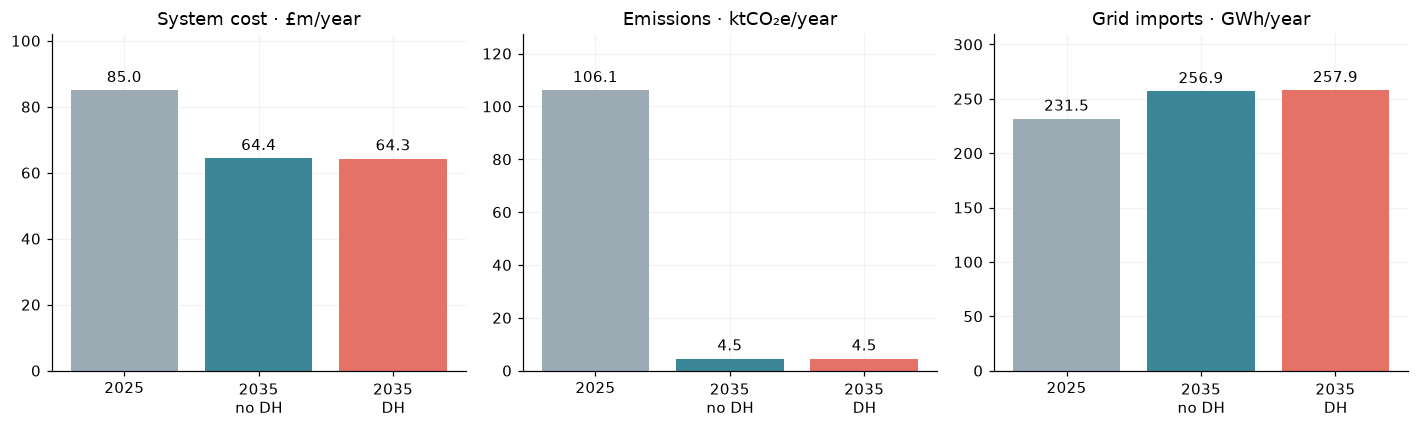

In [2]:
keys = {'cost_incl_nonres_mgbp': 'System cost (£m/yr)', 'emissions_total_kt': 'Emissions (ktCO₂e/yr)',
        'grid_import_gwh': 'Grid imports (GWh/yr)', 'pv_mw': 'PV capacity (MW)',
        'dwellings': 'Homes', 'dh_dwellings': 'DH homes'}
display(pd.DataFrame({'Five-area total': tidy(summary.reindex(keys)).values}, index=keys.values()).round(2))
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, key, title in zip(axes, ['cost_incl_nonres_mgbp', 'emissions_total_kt', 'grid_import_gwh'],
                        ['System cost · £m/year', 'Emissions · ktCO₂e/year', 'Grid imports · GWh/year']):
    values = [pd.read_csv(ROOT/'data'/c/'summary.csv', index_col=0).iloc[:,0][key] for c in CASES]
    bars = ax.bar(['2025', '2035\nno DH', '2035\nDH'], values, color=['#9caab4','#3c8797','#e57267'])
    ax.bar_label(bars, fmt='%.1f', padding=3); ax.set_title(title); ax.set_ylim(0, max(values)*1.2)
show()

## Heating and retrofit
R0: existing fabric · R1: light retrofit · R2: deep retrofit.

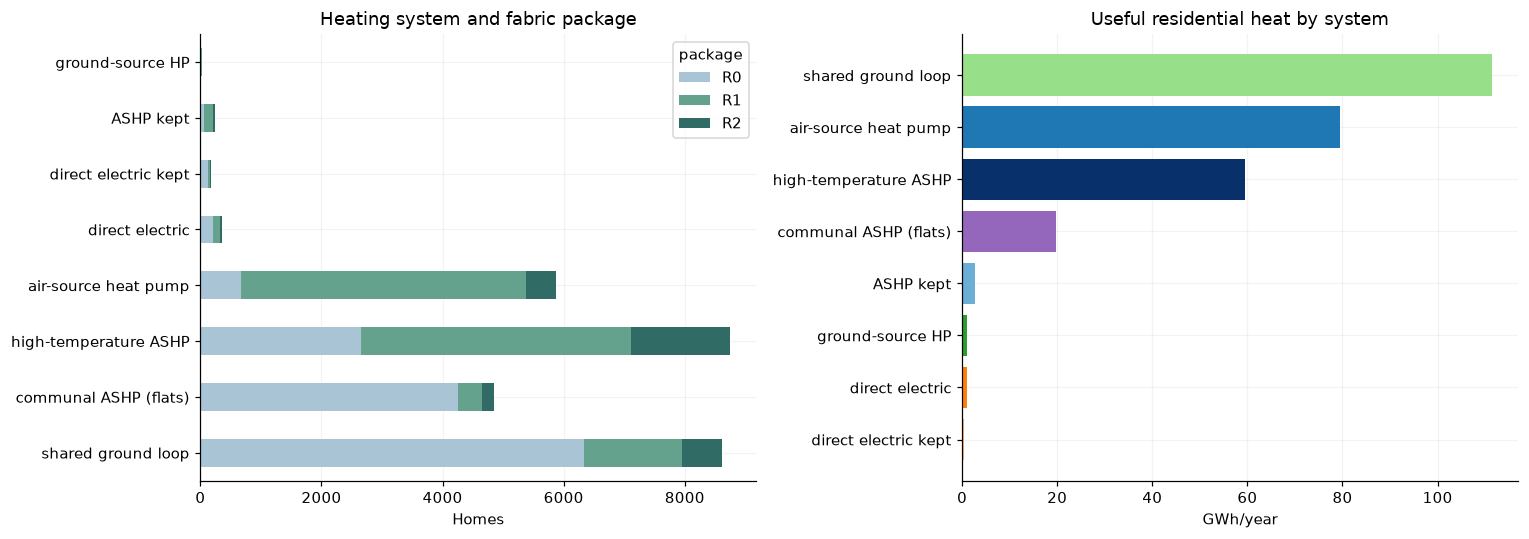

package,R0,R1,R2
system,,,
shared ground loop,6338.0,1621.5,648.5
communal ASHP (flats),4248.0,404.0,205.0
high-temperature ASHP,2647.0,4467.3,1628.7
air-source heat pump,671.5,4706.0,495.5
direct electric,201.5,118.9,34.3
direct electric kept,128.5,38.1,6.7
ASHP kept,57.5,145.5,33.0
ground-source HP,14.0,16.0,1.0


In [3]:
u = scope(uptake)
homes = u.pivot_table(index='system', columns='package', values='dwellings', aggfunc='sum', fill_value=0)
homes = homes.loc[homes.sum(axis=1) > .5].sort_values(by=list(homes.columns), ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
homes.rename(index=name).plot.barh(stacked=True, ax=axes[0], color=['#a9c4d5','#64a28e','#316b65'])
axes[0].set(xlabel='Homes', ylabel='', title='Heating system and fabric package')
heat = tidy(u.groupby('system').useful_heat_mwh.sum()/1000)
heat = heat[heat > .001].sort_values()
axes[1].barh([name(s) for s in heat.index], heat, color=[color(s) for s in heat.index])
axes[1].set(xlabel='GWh/year', title='Useful residential heat by system')
show()
display(homes.rename(index=name).round(1))

## Electricity demand and supply
Weighted annual totals. Network losses and storage explain differences between supply and final uses.

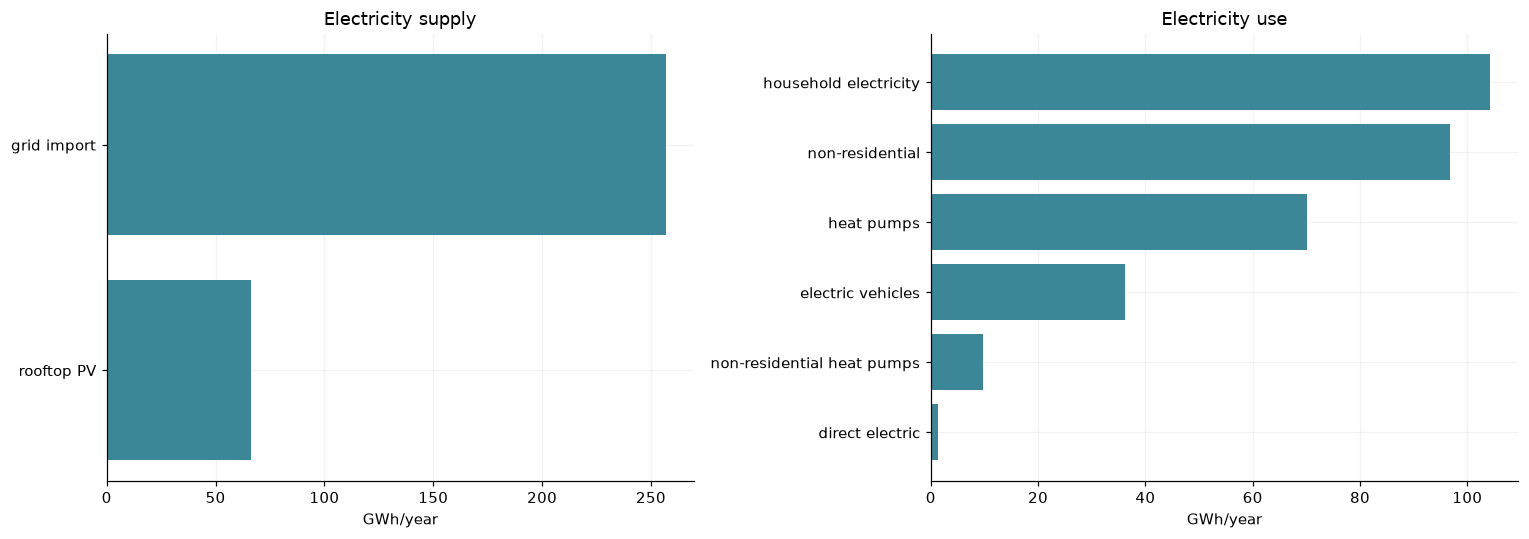

In [4]:
energy = scope(pd.read_csv(DATA/'annual_energy.csv'))
electricity = tidy(energy[energy.sector.eq('electricity')].groupby('item').gwh.sum())
suppliers = [c for c in ['grid import','rooftop PV','from batteries'] if c in electricity]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, series, title in [(axes[0], electricity.reindex(suppliers), 'Electricity supply'),
                           (axes[1], electricity.drop(suppliers + ['exported'], errors='ignore'), 'Electricity use')]:
    series = series[series.abs() > .001].sort_values()
    ax.barh(series.index, series.values, color='#3c8797'); ax.set(title=title, xlabel='GWh/year')
show()

## Dispatch
One solved representative day on the 2021 model calendar, with this scenario’s planning-year assumptions. Heat production includes storage charging and DH losses; useful demand excludes pipe losses.

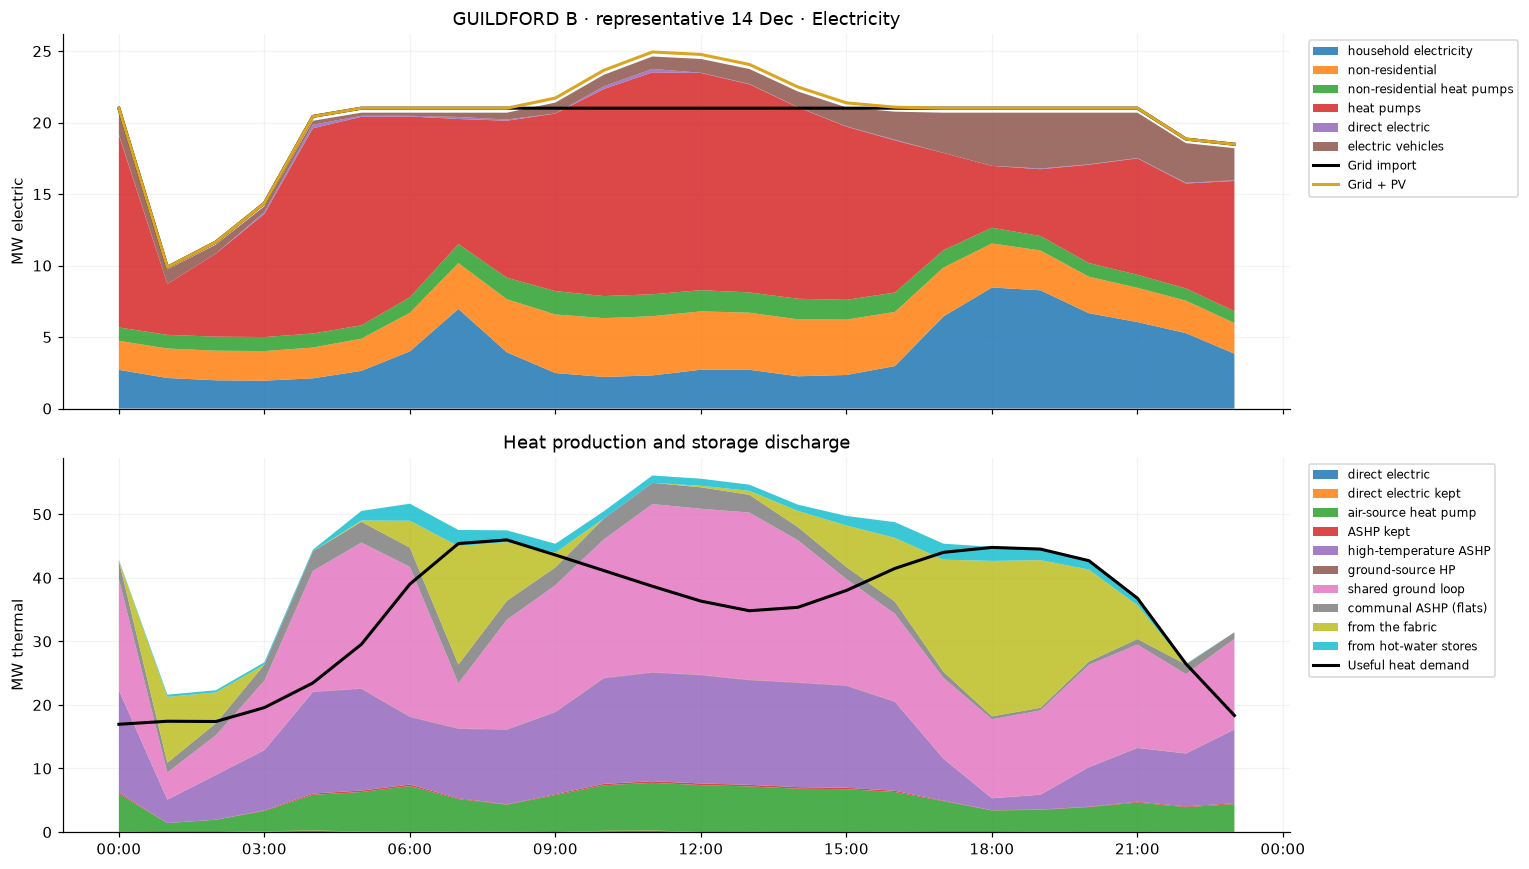

In [5]:
electric = pd.read_csv(DATA/'electricity.csv.gz', parse_dates=['time'])
heat = pd.read_csv(DATA/'heat.csv.gz', parse_dates=['time'])
area = AREA if AREA != 'All' else 'GUILDFORD B'
e = electric[electric.area.eq(area)].set_index('time').drop(columns='area')
h = heat[heat.area.eq(area)].set_index('time').drop(columns='area')
day = (e['grid import'].idxmax() if DAY == 'peak' else h['useful heat demand'].idxmin()).normalize() if DAY in ['peak','mild'] else pd.Timestamp(DAY)
assert day in e.index.normalize(), f'Choose one of: {sorted(set(e.index.strftime("%Y-%m-%d")))}'
idx = e.index.normalize() == day
ed, hd = e.loc[idx], h.loc[idx]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
uses = ed.drop(columns=['weight_h','grid import','rooftop PV','from batteries','exported'], errors='ignore')
uses = uses.loc[:, uses.clip(lower=0).max() > 1e-4].clip(lower=0)
axes[0].stackplot(uses.index, uses.T, labels=uses.columns, alpha=.85)
axes[0].plot(ed.index, ed['grid import'], color='black', label='Grid import', lw=2)
if 'rooftop PV' in ed: axes[0].plot(ed.index, ed['grid import']+ed['rooftop PV'], color='#daa520', label='Grid + PV', lw=2)
axes[0].set(title=f'{area} · representative {day:%d %b} · Electricity', ylabel='MW electric')
hs = hd.drop(columns=['weight_h','useful heat demand'], errors='ignore').clip(lower=0)
hs = hs.loc[:, hs.max() > 1e-4]
axes[1].stackplot(hs.index, hs.T, labels=hs.columns, alpha=.85)
axes[1].plot(hd.index, hd['useful heat demand'], color='black', label='Useful heat demand', lw=2)
axes[1].set(title='Heat production and storage discharge', ylabel='MW thermal')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
for ax in axes: ax.legend(loc='upper left', bbox_to_anchor=(1.01,1), fontsize=8)
show()

## Storage

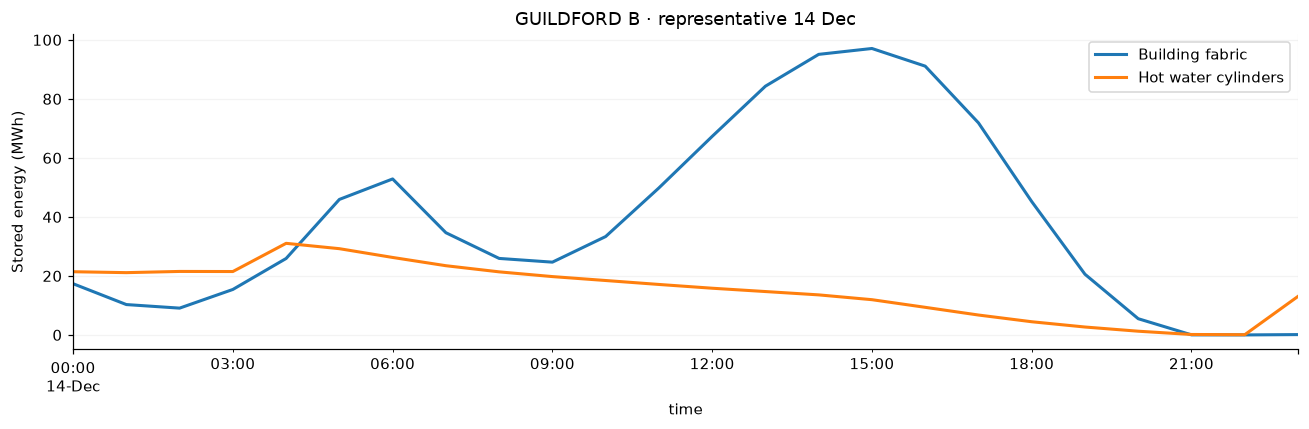

In [6]:
s = pd.read_csv(DATA/'storage.csv.gz', parse_dates=['time'])
s = s[s.area.eq(area)].set_index('time').drop(columns=['area','weight_h'])
s = s.loc[s.index.normalize() == day]
s = s.loc[:, s.max() > .001]
if len(s.columns):
    s.plot(lw=2, figsize=(12,4)); plt.ylabel('Stored energy (MWh)'); plt.title(f'{area} · representative {day:%d %b}'); show()
else:
    display(pd.DataFrame({'Storage': ['No material storage selected']}))

## Across the year
Repeated representative days on the model calendar; not a chronological full-year replay.

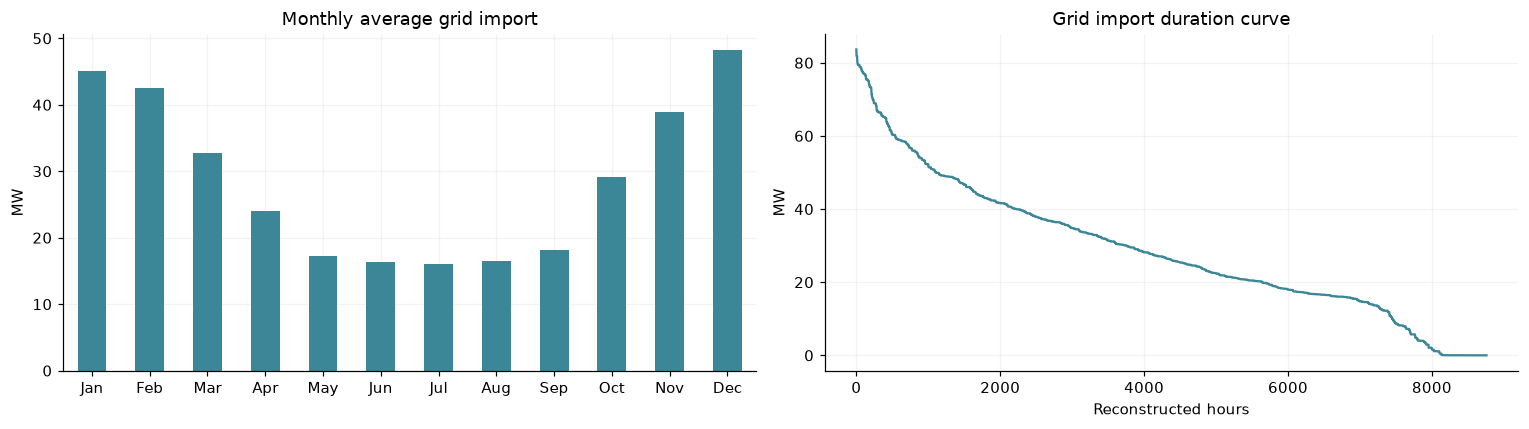

In [7]:
year = pd.read_csv(DATA/'reconstructed_import.csv.gz', index_col='time', parse_dates=True)
grid = year['grid_import'] if AREA == 'All' else year['primary:'+AREA]
fig, axes = plt.subplots(1,2,figsize=(14,4))
grid.resample('MS').mean().plot.bar(ax=axes[0], color='#3c8797')
axes[0].set_xticklabels(grid.resample('MS').mean().index.strftime('%b'), rotation=0)
axes[0].set(title='Monthly average grid import', ylabel='MW', xlabel='')
axes[1].plot(np.arange(len(grid)), np.sort(grid.values)[::-1],color='#3c8797')
axes[1].set(title='Grid import duration curve', xlabel='Reconstructed hours', ylabel='MW')
show()

## Costs

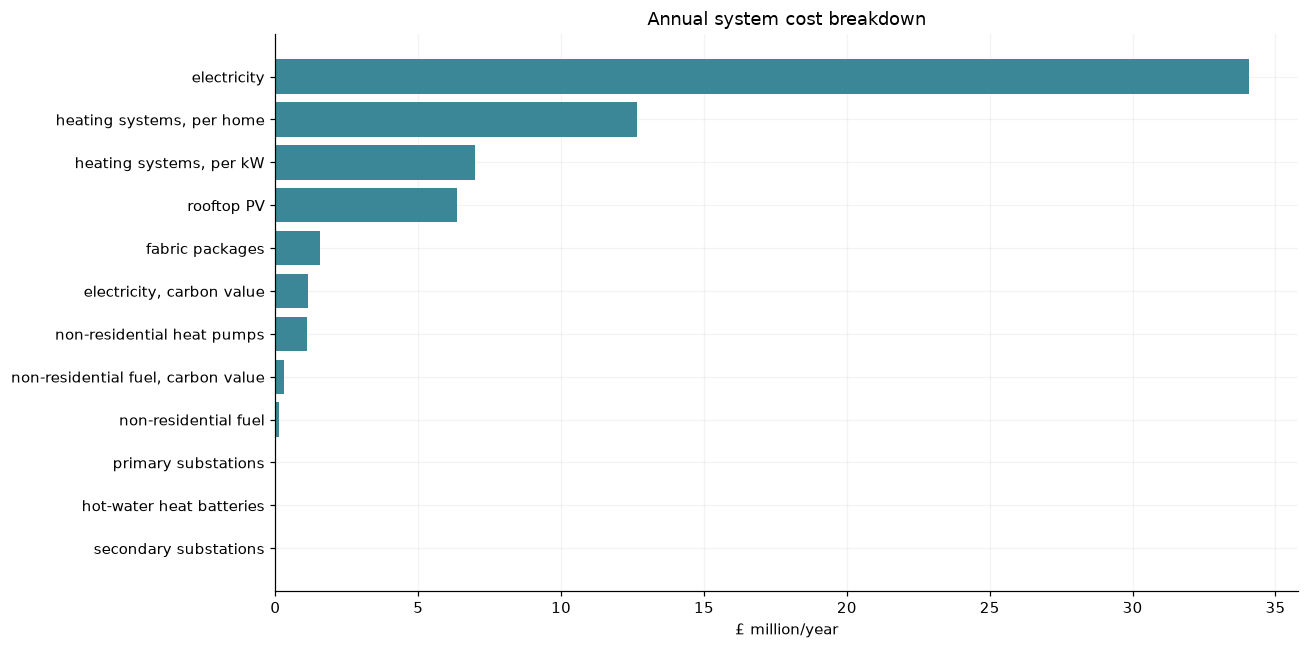

,£m/year,Share (%)
item,,
secondary substations,0.006,0.009
hot-water heat batteries,0.007,0.011
primary substations,0.018,0.027
non-residential fuel,0.143,0.222
"non-residential fuel, carbon value",0.315,0.490
non-residential heat pumps,1.120,1.740
"electricity, carbon value",1.126,1.749
fabric packages,1.577,2.449
rooftop PV,6.344,9.853


In [8]:
costs = scope(pd.read_csv(DATA/'costs.csv'))
c = tidy(costs.groupby('item').million_gbp_per_year.sum())
c = c[c.abs()>.001].sort_values()
fig, ax = plt.subplots(figsize=(12,6)); ax.barh(c.index,c.values,color=np.where(c.values<0,'#92b5a0','#3c8797'))
ax.set(xlabel='£ million/year', title='Annual system cost breakdown'); show()
display(pd.DataFrame({'£m/year': c, 'Share (%)': c/c.sum()*100}).round(3))

## Electricity network

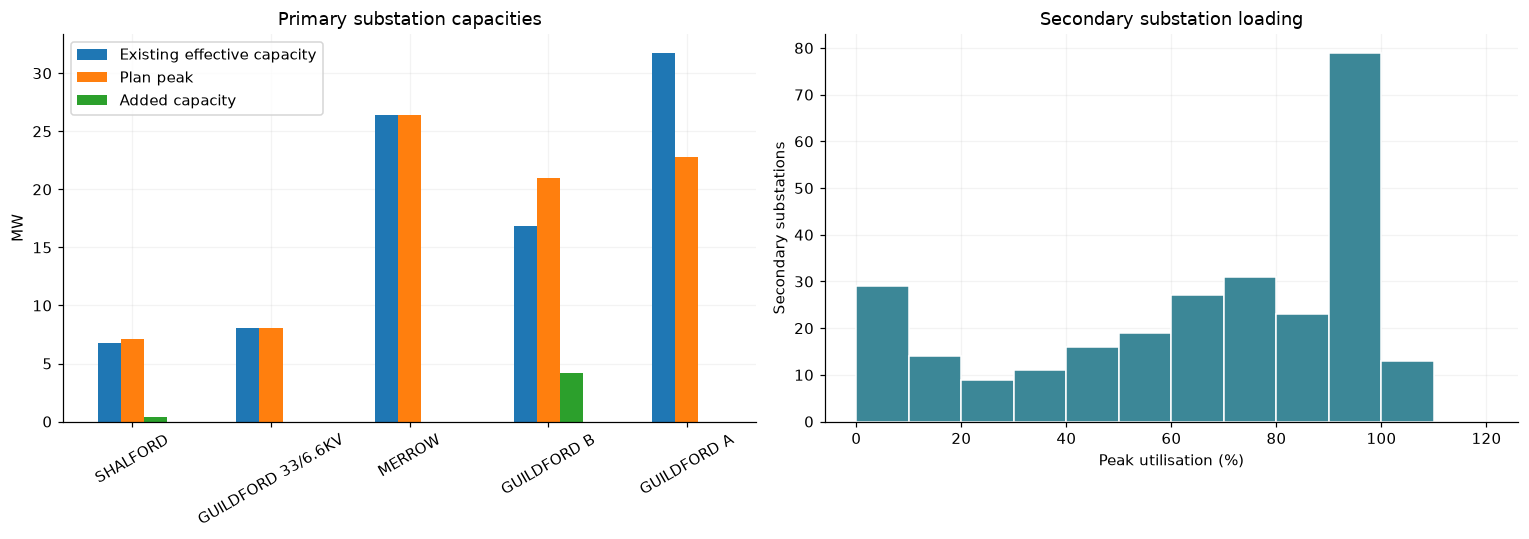

,zone,area,dwellings,peak_import_mw,reinforcement_mw,pv_mw
125,SUB:SPN-S000000174640,MERROW,199.0,0.458,0.158,0.436
128,SUB:SPN-S000000174722,MERROW,210.0,0.409,0.124,0.415
40,SUB:SPN-S000000171741,GUILDFORD 33/6.6KV,268.0,0.440,0.120,0.728
100,SUB:SPN-S000000171865,MERROW,119.0,0.354,0.069,0.288
141,SUB:SPN-R000000852116-000-001Z,GUILDFORD B,100.0,0.192,0.064,0.235
164,SUB:SPN-S000000171746,GUILDFORD B,209.0,0.355,0.056,0.463
71,SUB:SPN-S000000171815,MERROW,122.0,0.334,0.049,0.284
50,SUB:SPN-R000000843508-000-011Z,MERROW,23.0,0.139,0.044,0.079
6,SUB:SPN-S000000171681,SHALFORD,88.0,0.341,0.042,0.426
169,SUB:SPN-S000000171780,GUILDFORD B,295.0,0.512,0.037,0.637


In [9]:
p = primaries if AREA == 'All' else primaries[primaries.primary.eq(AREA)]
z = scope(zones).copy()
fig, axes = plt.subplots(1,2,figsize=(14,5))
p.set_index('primary')[['capacity_mw','plan_peak_mw','reinforcement_mw']].rename(columns={
    'capacity_mw':'Existing effective capacity','plan_peak_mw':'Plan peak','reinforcement_mw':'Added capacity'}).plot.bar(ax=axes[0])
axes[0].set(ylabel='MW',xlabel='',title='Primary substation capacities');axes[0].tick_params(axis='x',rotation=30)
axes[1].hist(z.utilisation*100, bins=np.arange(0,121,10),color='#3c8797',edgecolor='white')
axes[1].set(xlabel='Peak utilisation (%)',ylabel='Secondary substations',title='Secondary substation loading')
show()
display(z.nlargest(15,'reinforcement_mw')[['zone','area','dwellings','peak_import_mw','reinforcement_mw','pv_mw']].round(3))

## Spatial results
OpenStreetMap backgrounds. Static previews work on GitHub; run locally for the interactive map. Mapped home counts are rounded allocations.

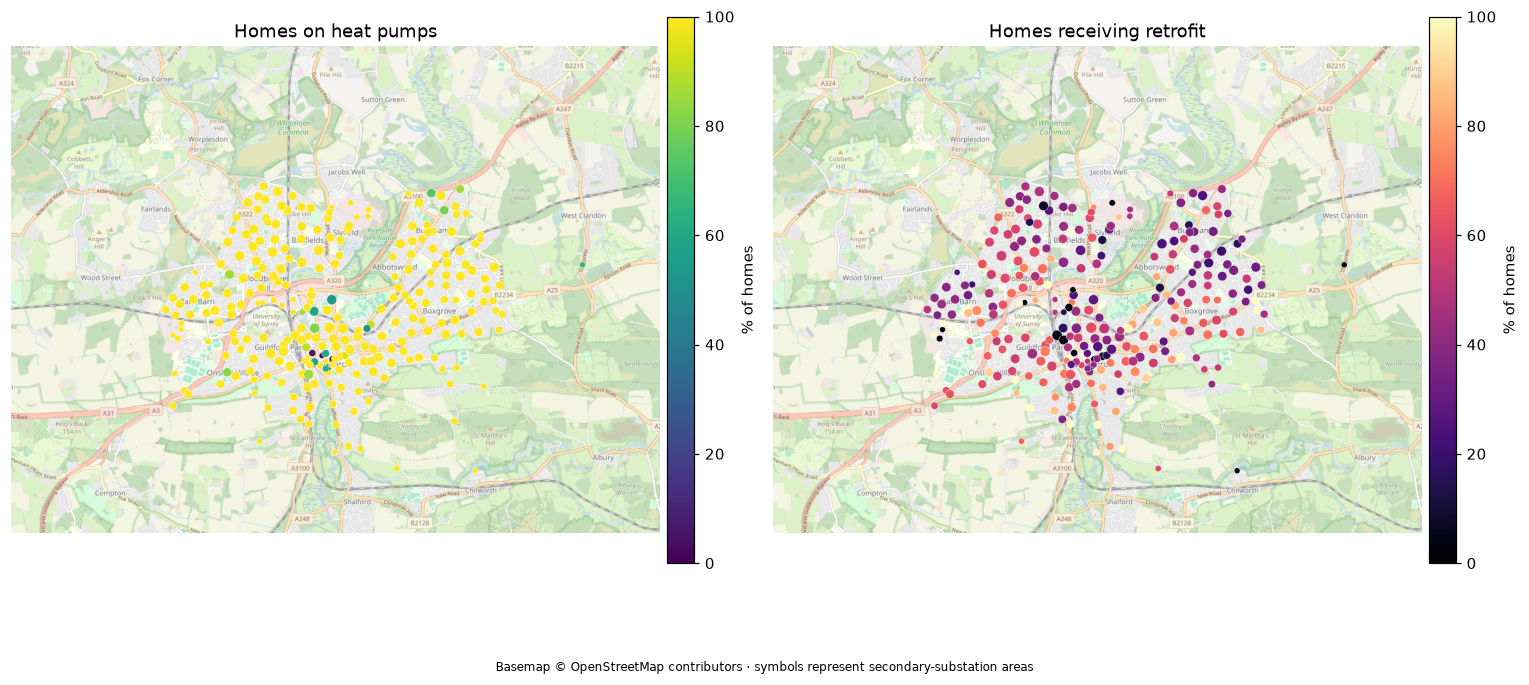

In [10]:
# Spatial results are aggregated to secondary substations.
spatial = mix.groupby('zone').apply(lambda g: pd.Series({
    'dh_homes':g.loc[g.system.eq('dh_connection'),'dwelling_count'].sum(),
    'retrofit_homes':g.loc[g.package.ne('R0'),'dwelling_count'].sum()}), include_groups=False)
mapped = scope(zones).merge(spatial, on='zone',how='left').fillna({'dh_homes':0,'retrofit_homes':0})
def mercator(lon,lat):
    return np.radians(lon)*6378137, np.log(np.tan(np.pi/4+np.radians(lat)/2))*6378137
extent = json.loads((ROOT/'data/osm_extent.json').read_text())
background = plt.imread(ROOT/'data/osm_basemap.png')
fig, axes = plt.subplots(1,2,figsize=(14,7))
for ax, column, title, cmap in [(axes[0],'heat_pump_dwellings','Homes on heat pumps','viridis'),
                                (axes[1],'dh_homes' if CASE=='with_dh' else 'retrofit_homes',
                                 'Homes on district heating' if CASE=='with_dh' else 'Homes receiving retrofit','magma')]:
    ax.imshow(background,extent=extent,alpha=.7)
    x,y=mercator(mapped.lon.to_numpy(),mapped.lat.to_numpy())
    pct=mapped[column]/mapped.dwellings*100
    sc=ax.scatter(x,y,c=pct,s=12+np.sqrt(mapped.dwellings)*2,cmap=cmap,vmin=0,vmax=100,edgecolor='white',lw=.25)
    ax.set_xlim(extent[:2]);ax.set_ylim(extent[2:]);ax.set_axis_off();ax.set_title(title)
    fig.colorbar(sc,ax=ax,fraction=.04,pad=.01,label='% of homes')
fig.text(.5,.025,'Basemap © OpenStreetMap contributors · symbols represent secondary-substation areas',ha='center',fontsize=8)
plt.tight_layout(rect=(0,.04,1,1));plt.show()

m = folium.Map(location=[mapped.lat.mean(),mapped.lon.mean()],zoom_start=13,tiles='OpenStreetMap')
for field,title,colour,visible in [('heat_pump_dwellings','Heat pump homes','#3c8797',CASE!='with_dh'),
                                  ('dh_homes','District heat homes','#e36761',CASE=='with_dh'),
                                  ('reinforcement_mw','Reinforcement','#825fa8',False)]:
    layer=folium.FeatureGroup(name=title,show=visible)
    for r in mapped.itertuples():
        value=float(getattr(r,field))
        if value>1e-4:
            folium.CircleMarker([r.lat,r.lon],radius=min(18,3+np.sqrt(value)),color=colour,weight=1,
                fill=True,fill_opacity=.75,tooltip=f'{r.area} | {r.zone} | {title}: {value:.2f}').add_to(layer)
    layer.add_to(m)
if CASE=='with_dh':
    folium.GeoJson(json.loads((ROOT/'data/dh_candidate_routes.geojson').read_text()),name='Candidate DH routes',
        style_function=lambda f:{'color':'#617b89','weight':2,'opacity':.65},show=False).add_to(m)
    centres=folium.FeatureGroup(name='Candidate energy centres',show=False)
    for r in pd.read_csv(ROOT/'data/dh_sites.csv').itertuples():
        folium.Marker([r.lat,r.lon],tooltip=f'Candidate zone {r.zone}',icon=folium.Icon(color='gray',icon='info-sign')).add_to(centres)
    centres.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m

## Data

In [11]:
display(summary.rename('value').to_frame().round(4))

,value
objective_mgbp,62.8033
objective_excl_committed_dh_mgbp,62.8033
committed_dh_pipe_cost_mgbp,0.0000
prebuilt_primary_cost_mgbp,0.0000
cost_incl_nonres_fuel_mgbp,63.2615
...,...
ev_peak_mw,12.6160
nonres_peak_mw,23.8584
n_scenarios,5.0000
n_scenarios_expected,5.0000
